# Bloque 2 — Demo v2: Comparativa de estrategias de embedding (Exploit.in)

Esta es la versión Exploit.in de la demo del Bloque 2: mismo experimento A/B/C/D/E, mismas explicaciones,
mismo código de análisis — cambia el dataset de origen (y cómo se obtienen las estrategias, ver más abajo).

¿Cuántos posts necesitamos embedear por usuario para obtener una representación fiel?

**Usamos Exploit.in (`data_Vruto/ExploitIn`) como dataset de referencia** porque:
- Los embeddings a nivel de post ya están precomputados (`exploitin_message_embeddings.npy`, 5.289 posts × 4096 dims) — construir los centroides B/C/D/E a partir de ellos es solo álgebra (numpy), no requiere GPU ni Ollama
- Es un foro real de cibercrimen (carding/hacking en ruso), con perfiles de 156 actores ya clasificados por LLM (`exploitin_user_profiles.json`) que dan contexto cualitativo a los resultados
- Es una muestra deliberadamente más pequeña que IronMarch (156 actores con ≥8 posts frente a 836), lo que la convierte en un contraste útil: veremos qué pasa con la comparativa de estrategias cuando hay menos usuarios prolíficos

### Las 5 estrategias

| Estrategia | Descripción | Ventaja | Limitación |
|---|---|---|---|
| **A** | Concatenar TODOS los posts → 1 embedding | Rápido, 1 llamada/usuario | Trunca a 50K chars — pierde contenido en usuarios prolíficos |
| **B** | 1 embedding por post → promedio (todos los posts) | Gold standard, nada se pierde | Computacionalmente inviable a escala |
| **C** | Top-50 posts más largos → promedio | Mucho más rápido que B | Pierde algo de fidelidad |
| **D** | Top-100 posts más largos → promedio | Mejor ratio calidad/coste | Punto óptimo identificado (en IronMarch) |
| **E** | Top-150 posts más largos → promedio | Mayor fidelidad que D | Rendimiento marginal decreciente |

> **Diferencia con la demo original**: en la versión IronMarch, las 5 estrategias estaban precalculadas en `.npz`
> (una corrida GPU de horas vía `scripts/precompute.py compare`). Aquí, como ya tenemos el embedding de cada
> post individual, las estrategias B/C/D/E se calculan en el propio notebook promediando esos vectores — es
> casi instantáneo. Solo la estrategia **A** (concatenar y re-embedear) necesita Ollama en vivo, y se salta con
> un aviso si no está disponible en esta máquina — igual que la demo original tolera estrategias `.npz` ausentes.

> **Prerrequisito**: tener `exploitin_sample_with_embeddings.parquet` y `exploitin_message_embeddings.npy` en
> `bloque5_ransomware/data_Vruto/ExploitIn/` (ya están precomputados en este repo, generados por
> `ExploitIn/03_embeddings.ipynb`).

**De dónde salen estos datos**: `exploitin_message_embeddings.npy` y `exploitin_sample_with_embeddings.parquet`
(en `data_Vruto/ExploitIn/`) vienen de una corrida real de `ExploitIn/03_embeddings.ipynb` — ese notebook generó
el embedding `qwen3-embedding` (4096 dims) de cada uno de los 5.289 posts clasificados, más las coordenadas UMAP
y el cluster de cada post. Aquí no se recalcula ningún post: solo se leen esos embeddings y se agregan de
distintas formas para obtener B/C/D/E. `src.embeddings.compute_actor_centroids` implementa exactamente esta
misma lógica (media de embeddings de post + normalización L2) cuando se parte de texto crudo en vez de
embeddings ya cacheados; `src.embeddings.embed_users` es la función que usamos en vivo para la estrategia A
(concatenación de texto + una sola llamada de embedding por usuario).

## 1. Cargar y calcular los embeddings por estrategia

Partimos de dos archivos:
- `exploitin_sample_with_embeddings.parquet`: 5.289 posts, uno por fila, con `username`, `content` y metadatos
- `exploitin_message_embeddings.npy`: matriz (5289, 4096) — la fila *i* es el embedding del post en la fila *i* del parquet (mismo orden)

A partir de aquí construimos cada estrategia:
- **B (full)**: para cada usuario con ≥8 posts, promedio (+ normalización L2) de TODOS sus embeddings de post
- **C/D/E (top-50/100/150)**: igual que B, pero solo con los N posts más largos de cada usuario (mismo criterio
  — longitud de `content` — que usa `_apply_top_n_longest` en `scripts/precompute.py`)
- **A (concat)**: requiere re-embedear el texto concatenado de cada usuario con Ollama — se intenta en vivo; si
  Ollama no está disponible en esta máquina, se salta con un aviso

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import spearmanr
from scipy.spatial.distance import cdist
import plotly.graph_objects as go
import plotly.express as px

# Directorio donde están los datos precomputados de Exploit.in
EI_DATA = Path('../bloque5_ransomware/data_Vruto/ExploitIn')
print('Buscando datos en:', EI_DATA.resolve())

sample = pd.read_parquet(EI_DATA / 'exploitin_sample_with_embeddings.parquet')
post_embeddings = np.load(EI_DATA / 'exploitin_message_embeddings.npy')
assert len(sample) == len(post_embeddings), 'posts y embeddings desalineados'
print(f'Posts: {len(sample):,}   Embeddings: {post_embeddings.shape}')

Buscando datos en: /home/drjekyll/FearOfTheDark/bloque5_ransomware/data_Vruto/ExploitIn
Posts: 5,289   Embeddings: (5289, 4096)


In [2]:
MIN_POSTS = 8  # mismo umbral que ExploitIn/03_embeddings.ipynb — con menos posts, el centroide no es fiable

sample = sample.copy()
sample['emb_idx'] = range(len(sample))
sample['_len'] = sample['content'].str.len()

def build_centroids(df: pd.DataFrame, top_n: int | None = None):
    """Centroide L2-normalizado por usuario: media de sus embeddings de post
    (opcionalmente, solo de los top_n posts más largos)."""
    ids, vecs = [], []
    for actor, group in df.groupby('username'):
        if len(group) < MIN_POSTS:
            continue
        g = group.sort_values('_len', ascending=False).head(top_n) if top_n else group
        v = post_embeddings[g['emb_idx'].tolist()]
        c = v.mean(axis=0)
        c /= np.linalg.norm(c)
        ids.append(actor)
        vecs.append(c)
    return ids, np.array(vecs, dtype=np.float32)

def try_strategy_a():
    """Estrategia A: concatenar todos los posts del usuario y embedear una vez. A
    diferencia de B/C/D/E, esto no se puede derivar de los embeddings de post ya
    cacheados — necesita una llamada real a Ollama."""
    try:
        import sys
        sys.path.insert(0, str(Path('..').resolve()))
        from src.embeddings import embed_users

        posts_for_a = sample.rename(columns={'username': 'userid', 'content': 'pagetext'})
        return embed_users(posts_for_a, min_posts=MIN_POSTS)
    except Exception as e:
        print(f'  A (concat): no disponible en esta máquina ({e.__class__.__name__}: {e})')
        print('              — necesita Ollama con el modelo qwen3-embedding corriendo localmente')
        return None

# Calcular cada estrategia
strats = {
    'A (concat)':  try_strategy_a(),
    'B (full)':    build_centroids(sample),
    'C (top-50)':  build_centroids(sample, 50),
    'D (top-100)': build_centroids(sample, 100),
    'E (top-150)': build_centroids(sample, 150),
}

for name, result in strats.items():
    if result is None:
        print(f'  {name}: ⚠️  no encontrado')
    else:
        ids, vecs = result
        print(f'  {name}: {len(ids):,} usuarios, dim={vecs.shape[1]}')

Embedding [qwen3-embedding]:   0%|          | 0/5 [00:00<?, ?it/s]


  A (concat): no disponible en esta máquina (ConnectionError: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download)
              — necesita Ollama con el modelo qwen3-embedding corriendo localmente
  A (concat): ⚠️  no encontrado
  B (full): 156 usuarios, dim=4096
  C (top-50): 156 usuarios, dim=4096
  D (top-100): 156 usuarios, dim=4096
  E (top-150): 156 usuarios, dim=4096


## 2. ¿Qué es el Spearman ρ y por qué lo usamos?

Queremos saber: si usamos solo 100 posts en lugar de todos, ¿obtenemos representaciones parecidas?

**No podemos comparar los vectores directamente** porque las estrategias no tienen exactamente los mismos usuarios. En cambio, comparamos el *ranking de similitudes*:

1. Para cada par de usuarios (A, B), calculamos su similitud coseno bajo la estrategia D
2. Hacemos lo mismo bajo la estrategia B (referencia)
3. Ordenamos todos los pares por similitud en cada estrategia
4. **Spearman ρ** mide si el orden es el mismo: ρ=1 significa rankings idénticos, ρ=0 es aleatorio

Si ρ(D vs B) sale muy cercano a 1, significa que casi toda la estructura de similitudes se preserva usando 100
posts en lugar de todos — spoiler: es justo lo que vas a ver en la celda de abajo, porque en esta muestra casi
ningún actor supera los 100 posts (más detalle en la sección 4).

### ¿Por qué similitud coseno?

La similitud coseno mide el ángulo entre dos vectores, no la distancia euclidiana.
Dos usuarios con el mismo estilo de escritura tendrán vectores que apuntan en la misma dirección aunque tengan distinto volumen de texto. Rango: -1 (opuestos) a 1 (idénticos).

In [3]:
def cosine_similarities_flat(ids, vecs):
    """Devuelve un dict {(uid_i, uid_j): similitud} para todos los pares."""
    # Normalizar vectores a longitud 1 para que el producto escalar = coseno
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    vecs_norm = vecs / np.where(norms == 0, 1, norms)
    sim_matrix = vecs_norm @ vecs_norm.T  # Matriz de similitudes NxN
    i_idx, j_idx = np.triu_indices(len(ids), k=1)  # Solo triángulo superior (sin diagonal)
    return {(ids[i], ids[j]): float(sim_matrix[i, j]) for i, j in zip(i_idx, j_idx)}

# Calcular similitudes para B (referencia) y para A, C, D, E
sim_cache = {}
for name, result in strats.items():
    if result is not None:
        ids, vecs = result
        sim_cache[name] = cosine_similarities_flat(ids, vecs)
        print(f'{name}: {len(sim_cache[name]):,} pares calculados')

B (full): 12,090 pares calculados
C (top-50): 12,090 pares calculados
D (top-100): 12,090 pares calculados
E (top-150): 12,090 pares calculados


In [4]:
def spearman_vs_reference(ref_sims: dict, cmp_sims: dict, label: str):
    """Calcula Spearman ρ entre dos conjuntos de similitudes, solo para pares comunes."""
    common_pairs = set(ref_sims.keys()) & set(cmp_sims.keys())
    if len(common_pairs) < 10:
        print(f'  {label}: insuficientes pares comunes ({len(common_pairs)})')
        return None
    ref_vals = [ref_sims[p] for p in common_pairs]
    cmp_vals = [cmp_sims[p] for p in common_pairs]
    rho, pval = spearmanr(ref_vals, cmp_vals)
    print(f'  {label:<20} ρ = {rho:.4f}   (n = {len(common_pairs):,} pares, p < 0.001)')
    return rho

ref = 'B (full)'
if ref in sim_cache:
    print(f'Spearman ρ comparando cada estrategia vs. {ref} (gold standard):\n')
    results = {}
    for name in ['A (concat)', 'C (top-50)', 'D (top-100)', 'E (top-150)']:
        if name in sim_cache:
            results[name] = spearman_vs_reference(sim_cache[ref], sim_cache[name], name)
else:
    print('⚠️  Estrategia B no disponible — usando D como referencia')
    ref = 'D (top-100)'
    print(f'Spearman ρ comparando vs. {ref}:\n')
    results = {}
    for name in ['A (concat)', 'C (top-50)', 'E (top-150)']:
        if name in sim_cache:
            results[name] = spearman_vs_reference(sim_cache[ref], sim_cache[name], name)

Spearman ρ comparando cada estrategia vs. B (full) (gold standard):

  C (top-50)           ρ = 0.9852   (n = 12,090 pares, p < 0.001)
  D (top-100)          ρ = 0.9990   (n = 12,090 pares, p < 0.001)
  E (top-150)          ρ = 1.0000   (n = 12,090 pares, p < 0.001)


## 3. Visualización — rendimiento marginal decreciente

El siguiente gráfico muestra cómo mejora el ρ al añadir más posts, frente al coste computacional de cada estrategia.

Como aquí partimos de embeddings de post ya cacheados, calcular B/C/D/E es casi instantáneo — no medimos minutos
reales de GPU en esta corrida. En su lugar usamos el **nº total de posts que habría que embedear** bajo cada
estrategia como proxy honesto de ese coste (el coste de embedear con Ollama escala aproximadamente lineal con el
nº de textos — ver `src.embeddings.embed_texts`).

El **rendimiento marginal decreciente** es el principio económico clave aquí: cada post adicional aporta menos
que el anterior. En algún punto, el coste de añadir más posts supera el beneficio en fidelidad.

In [5]:
# Nº total de posts que habría que embedear bajo cada estrategia (proxy de coste)
post_counts = sample.groupby('username').size()
qualifying = post_counts[post_counts >= MIN_POSTS]

cost_proxy = {
    'A (concat)':  len(qualifying),  # 1 llamada/usuario, independientemente de cuántos posts tenga
    'B (full)':    int(qualifying.sum()),
    'C (top-50)':  int(qualifying.clip(upper=50).sum()),
    'D (top-100)': int(qualifying.clip(upper=100).sum()),
    'E (top-150)': int(qualifying.clip(upper=150).sum()),
}

summary = pd.DataFrame([
    {
        'Estrategia': name,
        'Posts embebidos': cost_proxy[name],
        'ρ vs B': 1.0 if name == 'B (full)' else results.get(name),
    }
    for name in ['A (concat)', 'B (full)', 'C (top-50)', 'D (top-100)', 'E (top-150)']
])
print(summary.to_string(index=False))

 Estrategia  Posts embebidos   ρ vs B
 A (concat)              156      NaN
   B (full)             3538 1.000000
 C (top-50)             3164 0.985236
D (top-100)             3433 0.998967
E (top-150)             3532 0.999993


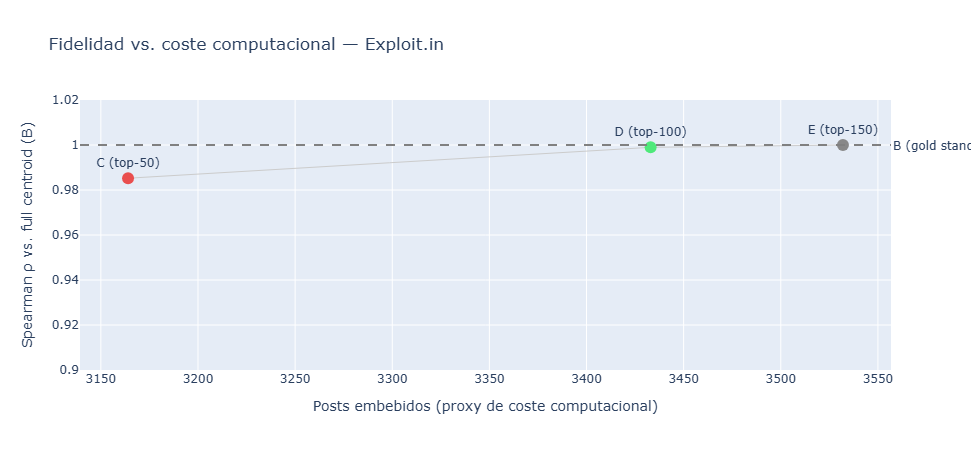

In [6]:
# Gráfico: ρ vs coste — la curva de rendimiento decreciente
plot_data = summary[summary['ρ vs B'].notna() & (summary['Estrategia'] != 'B (full)')].copy()

color_map = {'A (concat)': '#888', 'C (top-50)': '#E94E4E', 'D (top-100)': '#4EE97A', 'E (top-150)': '#888'}

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=plot_data['Posts embebidos'],
    y=plot_data['ρ vs B'],
    mode='lines+markers+text',
    text=plot_data['Estrategia'],
    textposition='top center',
    marker=dict(size=12, color=[color_map[n] for n in plot_data['Estrategia']]),
    line=dict(color='#ccc', width=1)
))
fig.add_hline(y=1.0, line_dash='dash', line_color='gray',
              annotation_text='B (gold standard)', annotation_position='right')
fig.update_layout(
    title='Fidelidad vs. coste computacional — Exploit.in',
    xaxis_title='Posts embebidos (proxy de coste computacional)',
    yaxis_title='Spearman ρ vs. full centroid (B)',
    yaxis=dict(range=[0.9, 1.02]),
    height=450
)
fig.show()

## 4. ¿Cuándo usar cada estrategia?

La elección depende de la distribución de posts por usuario en tu dataset.
**Antes de elegir estrategia, siempre mira el percentil 90 de posts/usuario.**

A diferencia de la sección 1-3 (que usan solo los 5.289 posts de la muestra clasificada), aquí leemos
`posts.parquet` — el foro completo de Exploit.in (80.891 posts) — para tener una imagen realista de cuánto
escriben los usuarios de verdad, no solo los que cayeron en la muestra.

In [7]:
try:
    posts_full = pd.read_parquet(EI_DATA / 'posts.parquet')
    post_counts_full = posts_full.groupby('author_id').size()
    p50 = post_counts_full.quantile(0.50)
    p90 = post_counts_full.quantile(0.90)
    p99 = post_counts_full.quantile(0.99)
    print(f'Exploit.in — distribución de posts por usuario (foro completo, {len(post_counts_full):,} autores):')
    print(f'  Mediana (P50): {p50:.0f} posts')
    print(f'  P90:           {p90:.0f} posts')
    print(f'  P99:           {p99:.0f} posts')
    print()
    if p90 < 50:
        print('→ Con P90 < 50: C, D y E darán resultados casi idénticos. Usar C.')
    elif p90 < 100:
        print('→ Con P90 < 100: D añade algo sobre C pero no mucho. C o D.')
    else:
        print(f'→ Con P90 = {p90:.0f}: D (top-100) es el punto óptimo confirmado.')
except FileNotFoundError:
    print('posts.parquet no disponible en data_Vruto/ExploitIn/')
    print()
    print('Regla general:')
    print('  P90 < 50  → usar C (top-50)')
    print('  P90 < 100 → C o D')
    print('  P90 ≥ 100 → D (top-100) es el óptimo')
    print('  P90 ≥ 150 → E si el presupuesto de GPU lo permite')

Exploit.in — distribución de posts por usuario (foro completo, 3,835 autores):
  Mediana (P50): 2 posts
  P90:           30 posts
  P99:           384 posts

→ Con P90 < 50: C, D y E darán resultados casi idénticos. Usar C.


## 5. Conclusión

**Para esta muestra de Exploit.in (156 actores con ≥8 posts en la muestra clasificada; P90 ≈ 30 posts/usuario en el foro completo):**

- ρ(C vs B) ≈ 0.985, ρ(D vs B) ≈ 0.999, ρ(E vs B) ≈ 1.000 — las tres estrategias de muestreo son casi indistinguibles de B
- Motivo: con P90 ≈ 30 posts/usuario, casi ningún actor supera el tope de 50/100/150 posts que definen C/D/E. Para la inmensa mayoría de usuarios, top-50 = top-100 = top-150 = todos sus posts. Las estrategias solo divergen en la cola de usuarios muy prolíficos (aquí, apenas 2 superan los 100 posts)
- **Con P90 < 50, la recomendación de la sección 4 aplica literalmente: usar C (top-50) es suficiente** — es la más barata de las tres y no deja fidelidad sobre la mesa
- **A (concat)** sigue siendo el baseline más rápido (1 llamada/usuario) cuando Ollama está disponible, pero trunca a 50K caracteres — solo importa para los actores más prolíficos

**Contraste con la demo IronMarch:** allí, con 836 usuarios muy activos (~190 posts/usuario de media), la
elección de estrategia sí importaba (D ganaba a C por +6 puntos de ρ). Aquí, con un dataset más pequeño y menos
usuarios prolíficos, la elección casi no importa — la regla del Bloque 2 (*mira siempre el P90 antes de elegir
estrategia*) es precisamente la que explica por qué.